In [1]:
import pandas as pd
import networkx as nx
import numpy as np
from collections import defaultdict
import time, json, os, re
import scipy.sparse as sp
import gurobipy as gp
from gurobipy import GRB
import json

In [2]:
from funciones import (obtener_comunas, dist, obtener_region, resultados_sampleo, ensure_dir,
                       safe_attr, parse_x_name, extraer_y_guardar_modelo, matriz_X_desde_modelo,
                       promedio_X, comparar_con_baseline, build_matrices_from_gurobi, delta_b_from_eps,
                       extraer_prob_centros)

In [3]:
from modelos import (modelo_con_limite, modelo_centros_fijos_con_limite,
                     modelo_sin_limite, modelo_IP)

In [4]:
comunas = pd.read_excel('DataEEUU/data_eeuu_procesada/comunas_ia.xlsx')
distancias = pd.read_excel('DataEEUU/data_eeuu_procesada/distancias_ia.xlsx')

In [5]:
with open('DataEEUU/data_eeuu_procesada/s_nuevo_ia.txt', 'r') as dict_file:
    dict_text = dict_file.read()
    dict_s = eval(dict_text)

In [6]:
R = obtener_comunas(comunas, "iowa")
#R = obtener_comunas(comunas, "wisconsin")
#R = obtener_comunas(comunas, "pennsylvania")


In [18]:
epsilons = np.round(np.arange(0.001, 0.81, 0.01), 2)

modelo_sin_limite_ia = None
epsilon_factible = None

for eps in epsilons:
    print(f"\nProbando epsilon = {eps:.2f}")

    modelo = modelo_sin_limite(eps, R, 17, dict_s, comunas)

    if modelo is not False and modelo is not None:
        modelo_sin_limite_ia = modelo
        epsilon_factible = eps
        print(f"\nFACTIBLE con epsilon = {eps:.2f}")
        break

if modelo_sin_limite_ia is None:
    print("\nNo se encontró epsilon factible en el rango probado.")
else:
    print(f"\nMenor epsilon factible encontrado: {epsilon_factible:.2f}")


Probando epsilon = 0.00
La cantidad de centros es 17
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-1355U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 21006 rows, 4556 columns and 59566 nonzeros
Model fingerprint: 0x8d82936f
Coefficient statistics:
  Matrix range     [1e+00, 2e+06]
  Objective range  [0e+00, 0e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+01]
Presolve removed 1424 rows and 268 columns
Presolve time: 0.06s
Presolved: 4489 rows, 20738 columns, 50186 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.19s
Ordering time: 0.21s

Barrier statistics:
 Dense cols : 67
 Free vars  : 134
 AA' NZ     : 1.526e+05
 Factor NZ  : 4.557e+05 (roughly 14 MB of memory)
 Factor Ops : 4.757e+07 (less than 1 second per iteration)
 T

In [7]:
from gurobipy import *
from gurobipy import Model
from funciones import calcular_poblacion_total, obtener_region, pob, codigo_com_cut, codigo_cut_com

import time
from datetime import datetime
import geopandas as gpd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
from openpyxl import load_workbook
import scipy as sp
from collections import defaultdict


In [8]:

modelo_sin_limite_ia = modelo_IP(0.001, R, 4, dict_s, comunas)

Set parameter Username
Set parameter LicenseID to value 2819129
Academic license - for non-commercial use only - expires 2027-05-06
La cantidad de centros es 4
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-1355U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 55464 rows, 9900 columns and 149538 nonzeros
Model fingerprint: 0x3bd8dd6f
Variable types: 0 continuous, 9900 integer (9900 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+05]
  Objective range  [0e+00, 0e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+00]
Presolve removed 45741 rows and 376 columns
Presolve time: 1.53s
Presolved: 9723 rows, 9524 columns, 47538 nonzeros
Variable types: 0 continuous, 9524 integer (9524 binary)

Root relaxation: objective 0.000000e+00, 8366 iterations, 1.04 seconds (2.06 work units)

    Nodes    |    

In [13]:
filas = []

for v in modelo_sin_limite_ia.getVars():
    if v.VarName.startswith("asignaciones_ij[") and v.X > 0.5:
        inside = v.VarName[v.VarName.find("[")+1:v.VarName.find("]")]
        i, j = [p.strip() for p in inside.split(",")]
        filas.append({"comuna": i, "centro": j, "x": v.X})

df_asig = pd.DataFrame(filas)
display(df_asig)

,comuna,centro,x
0,adair_county,adair_county,1.0
1,adams_county,adair_county,1.0
2,allamakee_county,allamakee_county,1.0
3,appanoose_county,adair_county,1.0
4,audubon_county,adair_county,1.0
...,...,...,...
94,winnebago_county,benton_county,1.0
95,winneshiek_county,allamakee_county,1.0
96,woodbury_county,adair_county,1.0
97,worth_county,benton_county,1.0


In [14]:
for v in modelo_sin_limite_ia.getVars():
    if v.VarName.startswith("centros_j[") and v.X > 0.5:
        print(v.VarName, v.X)

centros_j[adair_county] 1.0
centros_j[allamakee_county] 1.0
centros_j[benton_county] 1.0
centros_j[story_county] 1.0


In [21]:
modelo_sin_limite_ia.write("datos_modelo/modelo_ia.lp")

valores_ia = {v.VarName: v.X for v in modelo_sin_limite_ia.getVars()}

with open("datos_modelo/valores_ia.json", "w") as f:
    json.dump(valores_ia, f)

In [10]:
modelo_read = gp.read("datos_modelo/modelo_ia.lp")

with open("datos_modelo/valores_ia.json", "r") as f:
    valores_raw = json.load(f)
    
valores = {}
for k, v in valores_raw.items():
    valores[k.replace(" ", "_")] = v

Read LP format model from file datos_modelo/modelo_ia.lp
Reading time = 0.11 seconds
: 55464 rows, 9900 columns, 149538 nonzeros


In [9]:
def extraer_prob_centros(modelo, K, valores):
    centros_frac = []
    centros = []
    count_centros_fijados = 0
    
    for v in modelo.getVars():
        if v.VarName.startswith("centros_j") and valores[v.VarName] == 1.0:
            texto_1 = v.VarName
            comuna = texto_1[texto_1.find('[')+1 : texto_1.find(']')]
            centros.append(comuna)
            count_centros_fijados += 1

        elif v.VarName.startswith("centros_j") and valores[v.VarName] > 0.0 and valores[v.VarName] < 1.0:
            texto_1 = v.VarName
            comuna = texto_1[texto_1.find('[')+1 : texto_1.find(']')]
            centros_frac.append((comuna, valores[v.VarName]))

    top_centros_frac = sorted(centros_frac, key=lambda x: x[1], reverse=True)[0:(K-count_centros_fijados)]
    
    print(f"Hay {count_centros_fijados} centros fijados por el Modelo\n")
    print(f"Hay {len(centros_frac)} comunas con peso positivo\n")

    return count_centros_fijados, centros_frac, top_centros_frac

In [10]:
count_centros_fijados, centros_frac, top_centros_frac = extraer_prob_centros(modelo_sin_limite_ia, 4, valores)

NameError: name 'valores' is not defined

### Gráfico

In [1]:
from funciones_mapas_graficos import graficar_mapa_eeuu

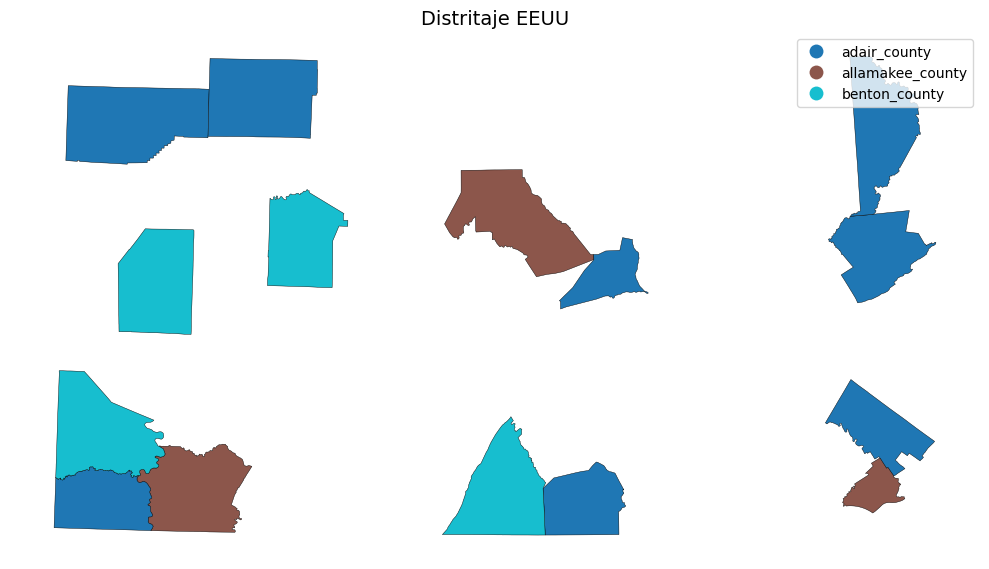

Mapa guardado en: mapa_pa.png


,county,pop,node_idx,geometry,comuna,centro
0,Adams County,103852.0,0,"POLYGON ((649998.906 -49456.596, 645712.896 -4...",adams_county,adair_county
1,Allegheny County,1250578.0,1,"POLYGON ((396569.173 19911.686, 395075.375 205...",allegheny_county,NaN
2,Armstrong County,65558.0,2,"POLYGON ((446129.949 48621.817, 446283.569 490...",armstrong_county,NaN
3,Beaver County,168215.0,3,"POLYGON ((378538.167 37866.522, 375854.571 379...",beaver_county,NaN
4,Bedford County,47577.0,4,"POLYGON ((532447.446 -49028.351, 531736.29 -48...",bedford_county,NaN
...,...,...,...,...,...,...
62,Washington County,209349.0,62,"POLYGON ((369821.363 -17974.147, 369572.859 -1...",washington_county,benton_county
63,Wayne County,51155.0,63,"POLYGON ((789319.13 121873.328, 789831.881 121...",wayne_county,adair_county
64,Westmoreland County,354663.0,64,"POLYGON ((420317.427 -2083.67, 420297.243 -209...",westmoreland_county,NaN
65,Wyoming County,26069.0,65,"POLYGON ((749679.833 138084.117, 748945.564 13...",wyoming_county,NaN


In [17]:
graficar_mapa_eeuu(
    modelo_sin_limite_ia,
    "DataEEUU/pa_paper/nodes.geojson",
    "mapa_pa.png"
)

In [18]:
gdf = gpd.read_file("DataEEUU/ia_paper/nodes.geojson")

print(len(gdf))
print(gdf["county"].nunique())

99
99


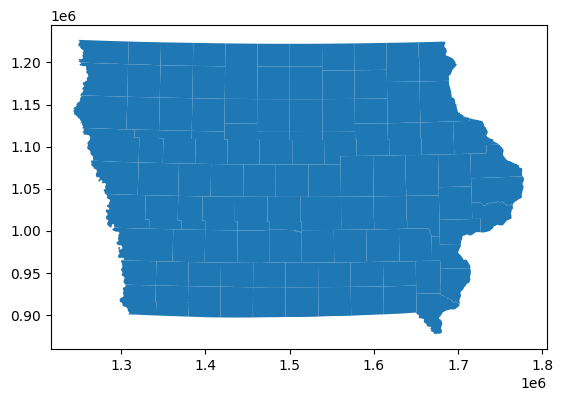

In [19]:
gdf.plot()
plt.show()

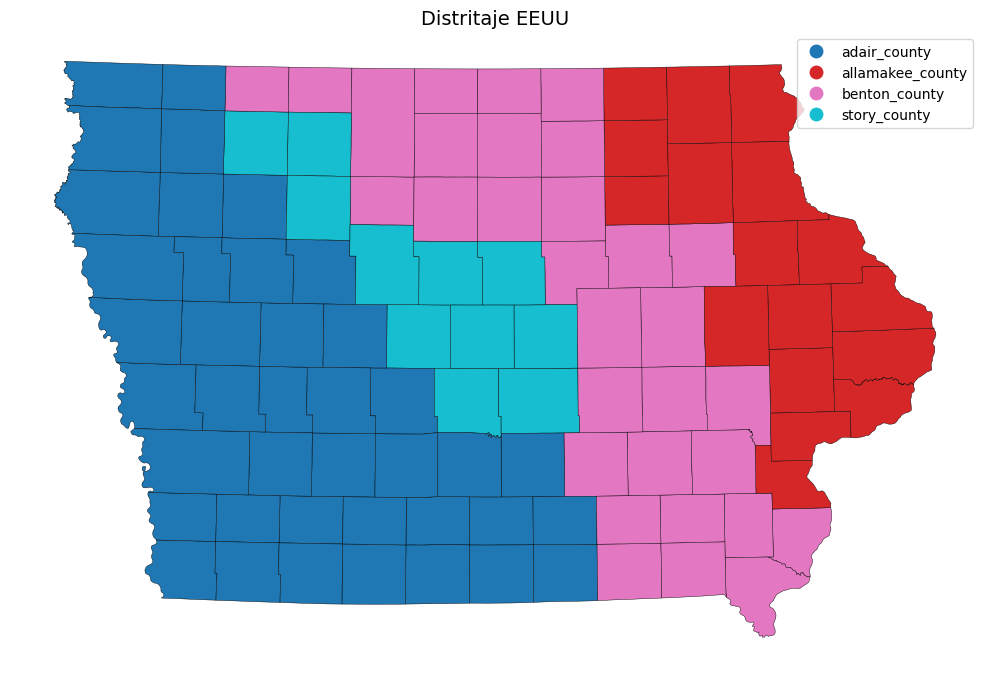

Mapa guardado en: mapa_ia.png
0
Series([], Name: comuna, dtype: object)


In [20]:
gdf_plot = graficar_mapa_eeuu(
    modelo_sin_limite_ia,
    "DataEEUU/ia_paper/nodes.geojson",
    "mapa_ia.png"
)

print(gdf_plot["centro"].isna().sum())
print(gdf_plot.loc[gdf_plot["centro"].isna(), "comuna"].head(20))